In [10]:
from cesnet_datazoo.datasets import CESNET_QUIC22
from cesnet_datazoo.config import DatasetConfig, AppSelection, ValidationApproach

dataset = CESNET_QUIC22("~/datasets/CESNET-QUIC22/", size="XS")

common_params = {
    "dataset": dataset,
    "apps_selection": AppSelection.ALL_KNOWN,
    "train_period_name": "W-2022-44",
    "val_approach": ValidationApproach.SPLIT_FROM_TRAIN,
    "train_val_split_fraction": 0.2,
    "use_packet_histograms": True,
}
dataset_config = DatasetConfig(**common_params)
dataset.set_dataset_config_and_initialize(dataset_config)
train_dataframe = dataset.get_train_df(flatten_ppi=True)
val_dataframe = dataset.get_val_df(flatten_ppi=True)
test_dataframe = dataset.get_test_df(flatten_ppi=True)

Loading data from dataloader


100%|██████████| 8162/8162 [00:16<00:00, 496.04it/s] 


Loading data from dataloader


100%|██████████| 192/192 [00:06<00:00, 30.46it/s]


Loading data from dataloader


100%|██████████| 1247/1247 [00:12<00:00, 97.26it/s] 


In [11]:
import numpy as np

def create_balanced_test_data(nfeatures, test_dataframe, nfrom_class = 100):
    grouped = test_dataframe.groupby("APP")

    X_arr = np.ndarray(shape = (nfrom_class * len(grouped), nfeatures))
    y_arr = np.ndarray(shape = (nfrom_class * len(grouped),))

    for index, i in enumerate(grouped):
        X_temp = i[1].drop(columns="APP").to_numpy()
        y_temp = i[1]["APP"].to_numpy()

        X_arr[index*nfrom_class:(index * nfrom_class) + nfrom_class] = X_temp[:nfrom_class]
        y_arr[index*nfrom_class:(index * nfrom_class) + nfrom_class] = y_temp[:nfrom_class]

    return (X_arr, y_arr)

In [154]:
from pyqlearning.q_learning import QLearning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

from collections import defaultdict
from dataclasses import dataclass, asdict
from math import log
import random

import pandas as pd
from tqdm import tqdm

import time

used_features  = [1, 1]
classes_amount = [6, 2]

@dataclass
class State_key:
    predict_proba : int # 6 values [0.15, 0.3, 0.45, 0.6, 0.75]
    hit : int

    def write(self):
        ret = "State_key("

        for index, field in enumerate(self.__dataclass_fields__):
            if used_features[index]:
                ret += field + "=" + str(getattr(self, field)) + ", "

        ret = ret[:-2] # remove trailing ", "

        ret += ")"

        return ret

    def __hash__(self):
        try:
            return self.hash
        except:
            value = 0
            multiplier = 1
            for index, field in enumerate(self.__dataclass_fields__):
                if used_features[index]:
                    value += getattr(self, field) * multiplier
                    multiplier *= classes_amount[index]

            self.hash = value

            return value

    def __eq__(self, other):
        if not isinstance(other, State_key) or self.__hash__() != other.__hash__():
            return False

        return True
        
class Q(QLearning):
    def big_test(self, path = "out.txt"):
        with open(path, "a") as f:
            f.write(str(self.to_i) + "/" + str(self.t + self.base_samples))
            
            clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            clf.fit(self.X_used[:self.to_i], self.y_used[:self.to_i])
            
            predict_arr = clf.predict(self.X_big_test)
            
            f.write(f"q_learning_f1: {f1_score(self.y_big_test, predict_arr, average='macro'):.4f}" + "\n")

            val = 0
            for _ in range(3):
                clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
                indices = np.random.choice(self.base_samples + self.t, self.to_i, replace=False)
        
                clf.fit(self.X[indices], self.y[indices])
                
                predict_arr = clf.predict(self.X_big_test)

                val += f1_score(self.y_big_test, predict_arr, average='macro')

            val /= 3
            f.write(f"random_learning_f1: {val:.4f}" + "\n")
            
            clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            clf.fit(self.X_u[:self.u_to_i], self.y_u[:self.u_to_i])

            predict_arr = clf.predict(self.X_big_test)
            
            f.write(f"uncertainty_sampling_f1: {f1_score(self.y_big_test, predict_arr, average='macro'):.4f} ({self.u_to_i} picked)" + "\n")

            clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            clf.fit(self.X[:self.base_samples + self.t], self.y[:self.base_samples + self.t])
            
            predict_arr = clf.predict(self.X_big_test)
            
            f.write(f"total_learning_f1: {f1_score(self.y_big_test, predict_arr, average='macro'):.4f}" + "\n")
            
            q_df = self.q_df
            q_df = q_df.sort_values(by=["q_value"], ascending=False)
            f.write(str(q_df.head()) + "\n\n")

    def get_clf_prediction(self, index):
        if index >= self.batch + self.last_batch_index:
            self.last_batch_index = index
            self.proba_arr = np.amax(self.clf.predict_proba(self.X[index:index + self.batch]), axis=1)
            predict_arr = self.clf.predict(self.X[index:index + self.batch])

            self.hit_arr = [el == self.y[index + i] for i, el in enumerate(predict_arr)]

            clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            clf.fit(self.X_u[:self.u_to_i], self.y_u[:self.u_to_i])
            self.unc_proba_arr = np.amax(clf.predict_proba(self.X[index:index + self.batch]), axis=1)

        self.last_proba = self.unc_proba_arr[index - self.last_batch_index]
        
        return (self.proba_arr[index - self.last_batch_index], int(self.hit_arr[index - self.last_batch_index]))

    def value_into_discrete(self, value, thresholds):
        for i, threshold in enumerate(thresholds):
            if value < threshold:
                return i
        return len(thresholds)

    def predict_proba_into_discrete(self, percent):
        return self.value_into_discrete(percent, self.PREDICT_PROBA_VALUES)

    def update_state(self, state_key, action_key):
        sample_index = self.base_i + self.t + 1

        next_class = self.y[sample_index]

        if action_key == 1:
            self.used += 1

        (proba, hit) = self.get_clf_prediction(sample_index)
        proba = self.predict_proba_into_discrete(proba)

        return State_key(proba, hit)

    def initialize(self, cols, iters, batch, already_used, epsilon = 0.9, alpha = 0.2, gamma = 0.9):
        self.q_count = defaultdict(int)

        self.epsilon_greedy_rate = epsilon
        self.alpha_value         = alpha
        self.gamma_value         = gamma

        self.m_depth = 15

        self.PREDICT_PROBA_VALUES = [0.15, 0.3, 0.45, 0.6, 0.75]

        self.func_time = 0 # debug
        self.u_threshold = 0.4
        self.last_proba = 0
        
        self.batch = batch
        self.last_batch_index = -1

        self.used         = already_used
        self.base_samples = already_used
        self.base_i       = already_used - 1
        self.to_i         = already_used
        self.u_to_i       = already_used

        self.X_u    = np.ndarray(shape = (iters + already_used, cols))
        self.y_u    = np.ndarray(shape = (iters + already_used,))
        self.X_used = np.ndarray(shape = (iters + already_used, cols))
        self.y_used = np.ndarray(shape = (iters + already_used,))
        self.last_f1 = 0

        self.X_u[:self.base_samples]    = self.X[:self.base_samples]
        self.y_u[:self.base_samples]    = self.y[:self.base_samples]
        self.X_used[:self.base_samples] = self.X[:self.base_samples]
        self.y_used[:self.base_samples] = self.y[:self.base_samples]

        self.clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
        self.last_f1 = self.test_acc()

        self.vis_values = { "random": [],
                            "uncertainty": [],
                            "qlearning": [] }
    
    def extract_possible_actions(self, state_key):
        return list({0, 1})

    def select_action(self, state_key, next_action_list):
        epsilon_greedy_flag = bool(np.random.binomial(n=1, p=self.epsilon_greedy_rate))

        if epsilon_greedy_flag is False:
            action_key = random.choice(next_action_list)
        else:
            action_key = self.predict_next_action(state_key, next_action_list)

        return action_key

    def train_clf(self, clf):
        clf.fit(self.X_used[:self.to_i], 
                self.y_used[:self.to_i])

    def test_acc(self):
        self.clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)

        self.train_clf(self.clf)

        predict_arr = self.clf.predict(self.X_test)

        return f1_score(self.y_test, predict_arr, average="macro")
    
    def observe_reward_value(self, state_key, action_key):
        cur_f1 = self.test_acc()
        reward = cur_f1 - self.last_f1

        self.last_f1 = cur_f1

        return reward

    def visualize_learning_result(self, state_key):
        # uncertain
        clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
        clf.fit(self.X_u[:self.u_to_i], self.y_u[:self.u_to_i])
        predict_arr = clf.predict(self.X_test)
        u_f1 = f1_score(self.y_test, predict_arr, average='macro')

        # random
        clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
        indices = np.random.choice(self.base_samples + self.t, self.to_i, replace=False)
        clf.fit(self.X[indices], self.y[indices])
        predict_arr = clf.predict(self.X_test)
        r_f1 = f1_score(self.y_test, predict_arr, average='macro')

        self.vis_values["random"].append(r_f1)
        self.vis_values["uncertainty"].append(u_f1)
        self.vis_values["qlearning"].append(self.last_f1)

    def uncertainty(self):
        if self.last_proba < self.u_threshold:
            self.X_u[self.u_to_i] = self.X[self.base_i + self.t]
            self.y_u[self.u_to_i] = self.y[self.base_i + self.t]
            self.u_to_i += 1

    def learn(self, state_key, batch, limit=1000, increased_rd = 1, decrease_alpha = 0):
        self.t = 1
        last_t = 1

        self.batch = batch

        seen_states = []

        for _ in tqdm(range(1, limit + 1)):
            if self.t - last_t > 1000:
                self.big_test()
                last_t = self.t

            self.epsilon_greedy_rate = min(self.t / increased_rd, 0.9)
            self.alpha_value = max(self.alpha_value - decrease_alpha, 0.05)

            next_action_list = self.extract_possible_actions(state_key)
            action_key = self.select_action(
                state_key=state_key,
                next_action_list=next_action_list
            )

            # reward_value = self.observe_reward_value(state_key, action_key)
            if action_key == 1:
                self.X_used[self.to_i] = self.X[self.base_i + self.t]
                self.y_used[self.to_i] = self.y[self.base_i + self.t]
                self.to_i += 1
            
            if self.t % batch == 0:
                reward = self.observe_reward_value(state_key, action_key)

            self.uncertainty()

            # Max-Q-Value in next action time.
            next_state_key = self.update_state(
                state_key=state_key,
                action_key=action_key
            )

            next_next_action_list = self.extract_possible_actions(next_state_key)
            next_action_key = self.predict_next_action(next_state_key, next_next_action_list)
            next_max_q = self.extract_q_df(next_state_key, next_action_key)

            seen_states.append([state_key, action_key, next_max_q])

            if self.t % batch == 0:
                # reward = self.observe_reward_value(state_key, action_key)

                for state in seen_states:
                    (state_key, action_key, next_max_q) = state
                    
                    temp_reward = reward

                    if action_key == 0:
                        temp_reward = -reward

                    self.update_q(
                        state_key=state_key,
                        action_key=action_key,
                        reward_value=temp_reward,
                        next_max_q=next_max_q
                    )

                seen_states = []

            # Update State.
            state_key = next_state_key

            # Normalize.
            self.normalize_q_value()
            self.normalize_r_value()

            # Vis.
            if self.t % batch == 0:
                self.visualize_learning_result(state_key)
                
            # Check.
            if self.check_the_end_flag(state_key) is True:
                break

            self.t += 1


In [180]:
increased_rd = 300 # increased randomness for n iters
decrease_alpha = 0.00001
iters = 2000
base_samples_amount = 200
epsilon = 0.90
alpha = 0.1
gamma = 0.95
batch = 1

q = Q()    

q.X = train_dataframe.drop(columns="APP").to_numpy()
q.y = train_dataframe["APP"].to_numpy()

q.X_big_test = test_dataframe.drop(columns="APP").to_numpy()[:100000]
q.y_big_test = test_dataframe["APP"].to_numpy()[:100000]

nfeatures = q.X.shape[1]

(q.X_test, q.y_test) = create_balanced_test_data(nfeatures, test_dataframe, nfrom_class = 100)

q.initialize(nfeatures, iters, batch, base_samples_amount, epsilon, alpha, gamma)

state_key = q.update_state(State_key(0, 0), 0)

q.learn(state_key, batch, iters, increased_rd, decrease_alpha)

100%|██████████| 2000/2000 [19:07<00:00,  1.74it/s]


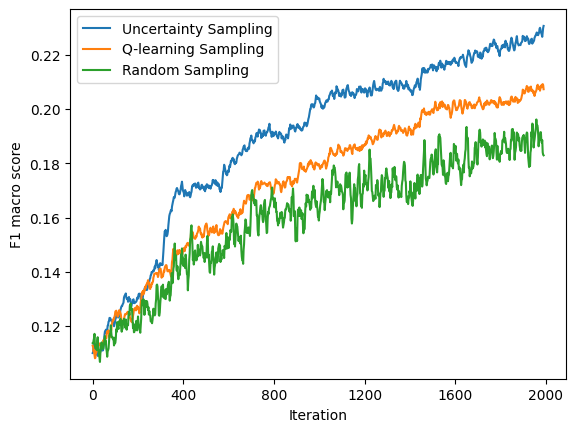

1303
1215
State_key(predict_proba=0, hit=0) 1 0.002768897396260132 
State_key(predict_proba=4, hit=1) 1 0.002124186340134479 
State_key(predict_proba=3, hit=0) 0 0.0020008600458527523 
State_key(predict_proba=3, hit=1) 0 0.0014689385319474712 
State_key(predict_proba=4, hit=0) 1 0.00124641136622149 
State_key(predict_proba=0, hit=1) 0 0.0009325212048921347 
State_key(predict_proba=5, hit=1) 0 0.0007256370358276342 
State_key(predict_proba=2, hit=0) 0 0.0006175716239929404 
State_key(predict_proba=2, hit=1) 0 0.0003135370088782381 
State_key(predict_proba=4, hit=1) 0 0.0003128587896062578 
State_key(predict_proba=2, hit=1) 1 0.00023955139893466987 
State_key(predict_proba=5, hit=0) 0 0.0 
State_key(predict_proba=5, hit=0) 1 -4.338732484870472e-05 
State_key(predict_proba=1, hit=1) 0 -5.529708870568381e-05 
State_key(predict_proba=0, hit=0) 0 -0.0003660823369411946 
State_key(predict_proba=1, hit=0) 1 -0.00045541965705659765 
State_key(predict_proba=0, hit=1) 1 -0.0005091673732691763 
St

In [181]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

fig, ax = plt.subplots()

def fmt_two_digits(x, pos):
    return int(x * batch)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_two_digits))

plt.plot(moving_average(q.vis_values["uncertainty"], 5), label="Uncertainty Sampling")
plt.plot(moving_average(q.vis_values["qlearning"], 5), label="Q-learning Sampling")
plt.plot(moving_average(q.vis_values["random"], 5), label="Random Sampling")
plt.xlabel("Iteration")
plt.ylabel("F1 macro score")
plt.legend()
plt.show()

print(q.u_to_i)
print(q.to_i)

for index, row in q.q_df.sort_values(by=["q_value"], ascending=False).iterrows():
    for el in row:
        print(str(el), end = " ")
    print()